# Acidification Profile — Session 2 (5 May 2026)

**Contact:** Dimitri Bocquel  
**Authors:** Lilandra Albert-Lavault & Samuele Moungang  
**Data collected:** 5 May 2026

| Source | File | Resolution | Channels |
|--------|------|------------|----------|
| Hanna edge PHLOT002 | `trace_pH_hannah_05052026.csv` | 1 min | pH, mV, T°C |
| Elpro Ecolog TP4-L | `trace_temp_05052026.csv` | 16 s | T°C (ambient) |

**Fresh yield (Session 2):** 33.26 kg → **11.8 %**  
**Fresh yield (Session 1, 28 Apr):** 34.34 kg / 282 kg → **12.17 %**

---

## Pipeline
1. **Load & Inspect** raw data
2. **Resampling** — 1-min median + Savitzky-Golay smoothing *(no interpolation needed — 0 gaps)*
3. **Elpro alignment** — resample 16 s → 1 min, filter artefacts
4. **Nernst correction** — with measured product temperature (better accuracy than Session 1)
5. **Cross-session comparison** — Session 1 Hannah (PHLOT001) vs Session 2 (PHLOT002)
6. **Feature extraction** — quantify acidification curve shape
7. **Quality table** — correlate features with fresh yield

---
## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.signal import savgol_filter

plt.rcParams.update({
    'figure.figsize': (14, 4.5),
    'figure.dpi': 120,
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

R    = 8.314
F    = 96485.0
LN10 = np.log(10)

def nernst_slope(T_celsius):
    return -(R * (T_celsius + 273.15) * LN10 / F) * 1000

def nernst_correct(pH_meas, T_meas_C, T_cal_C=25.0, pH_iso=7.0):
    T_meas_K = T_meas_C + 273.15
    T_cal_K  = T_cal_C  + 273.15
    return pH_iso + (pH_meas - pH_iso) * (T_meas_K / T_cal_K)

T_CAL = 25.0
SG_WINDOW = 11
SG_POLY   = 3

print(f'Nernst slope @ {T_CAL}°C : {nernst_slope(T_CAL):.3f} mV/pH')
print(f'Nernst slope @ 37°C    : {nernst_slope(37):.3f} mV/pH')

Nernst slope @ 25.0°C : -59.156 mV/pH
Nernst slope @ 37°C    : -61.537 mV/pH


---
## 1. Load & Inspect Raw Data

In [2]:
# ── Hanna PHLOT002 — pH + mV + product temperature ───────────────────────────
df_ph = pd.read_csv(
    'data_5_mais/trace_pH_hannah_05052026.csv',
    index_col='datetime', parse_dates=True
)
df_ph = df_ph[(df_ph['pH'] >= 3.5) & (df_ph['pH'] <= 7.0)].copy()

# ── Elpro Ecolog — ambient temperature ───────────────────────────────────────
df_elpro = pd.read_csv(
    'data_5_mais/trace_temp_05052026.csv',
    index_col='datetime', parse_dates=True
)
# Filter artefacts: values above 50°C are probe-removal spikes
df_elpro = df_elpro[df_elpro['temp_C'] <= 50.0].copy()

print(f'PHLOT002  : {len(df_ph):,} pts | {df_ph.index[0]} → {df_ph.index[-1]}')
print(f'  pH      : {df_ph.pH.min():.2f} → {df_ph.pH.max():.2f}')
print(f'  Temp    : {df_ph.temp_C.min():.1f} → {df_ph.temp_C.max():.1f} °C  (product)')
print()
print(f'Elpro     : {len(df_elpro):,} pts | {df_elpro.index[0]} → {df_elpro.index[-1]}')
print(f'  Temp    : {df_elpro.temp_C.min():.1f} → {df_elpro.temp_C.max():.1f} °C  (ambient)')

# Gap check
gaps = df_ph.index.to_series().diff().dt.total_seconds()
print(f'\nGaps > 2 min in PHLOT002: {(gaps > 120).sum()}')

PHLOT002  : 286 pts | 2026-05-05 11:23:27 → 2026-05-05 16:08:28
  pH      : 5.15 → 6.42
  Temp    : 25.7 → 40.1 °C  (product)

Elpro     : 5,174 pts | 2026-05-05 07:14:36 → 2026-05-06 07:05:48
  Temp    : 16.1 → 41.1 °C  (ambient)

Gaps > 2 min in PHLOT002: 0


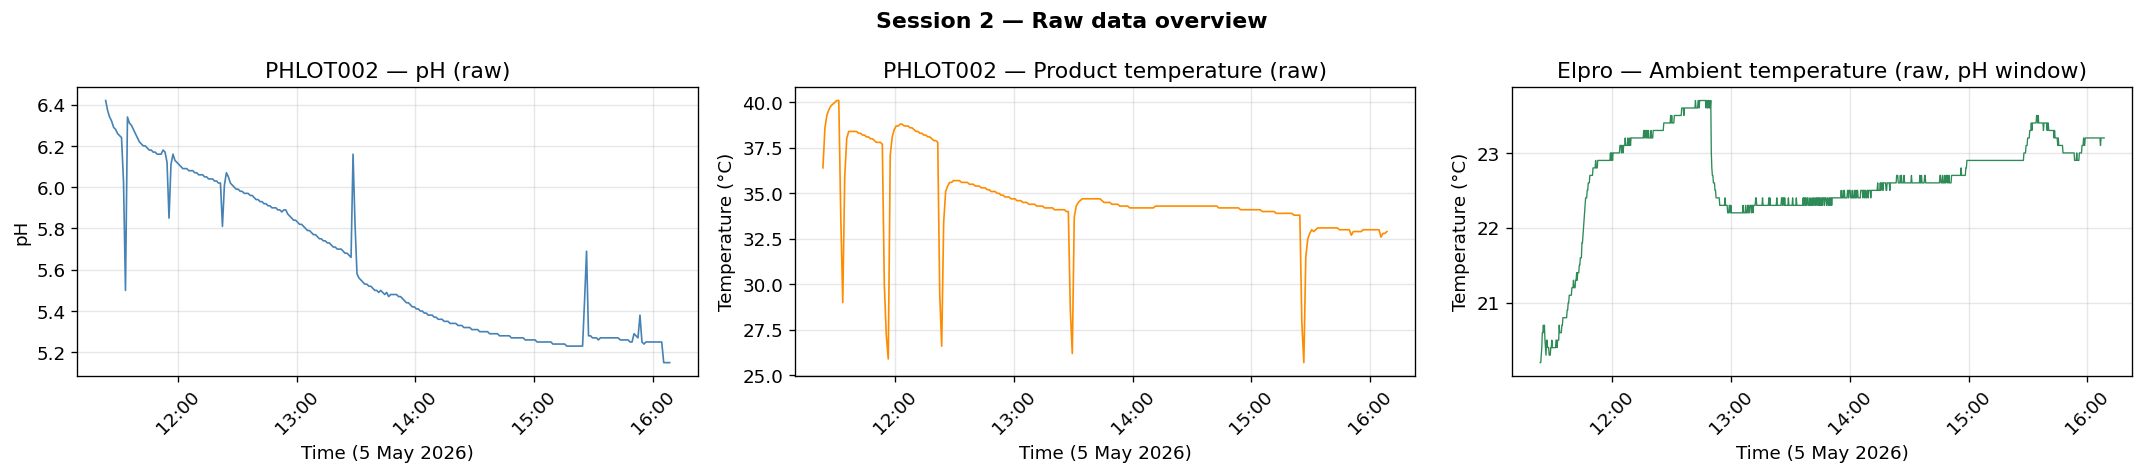

In [3]:
# ── Raw overview plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fmt = mdates.DateFormatter('%H:%M')
loc = mdates.HourLocator(interval=1)

axes[0].plot(df_ph.index, df_ph['pH'], color='steelblue', linewidth=1.0)
axes[0].set_title('PHLOT002 — pH (raw)')
axes[0].set_ylabel('pH')

axes[1].plot(df_ph.index, df_ph['temp_C'], color='darkorange', linewidth=1.0)
axes[1].set_title('PHLOT002 — Product temperature (raw)')
axes[1].set_ylabel('Temperature (°C)')

# Elpro — restrict to pH measurement window for readability
elpro_window = df_elpro[
    (df_elpro.index >= df_ph.index[0]) &
    (df_elpro.index <= df_ph.index[-1])
]
axes[2].plot(elpro_window.index, elpro_window['temp_C'], color='seagreen', linewidth=0.8)
axes[2].set_title('Elpro — Ambient temperature (raw, pH window)')
axes[2].set_ylabel('Temperature (°C)')

for ax in axes:
    ax.xaxis.set_major_formatter(fmt)
    ax.xaxis.set_major_locator(loc)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.set_xlabel('Time (5 May 2026)')

plt.suptitle('Session 2 — Raw data overview', fontweight='bold')
plt.tight_layout()
plt.savefig('may5_01_raw.png', bbox_inches='tight')
plt.show()

---
## 2. Resampling + Savitzky-Golay Smoothing

PHLOT002 already logs at 1-min intervals with **0 gaps** — no interpolation required.  
Savitzky-Golay (window = 11 min, degree = 3) is applied to reduce noise before derivative computation.

After resampling: 286 points


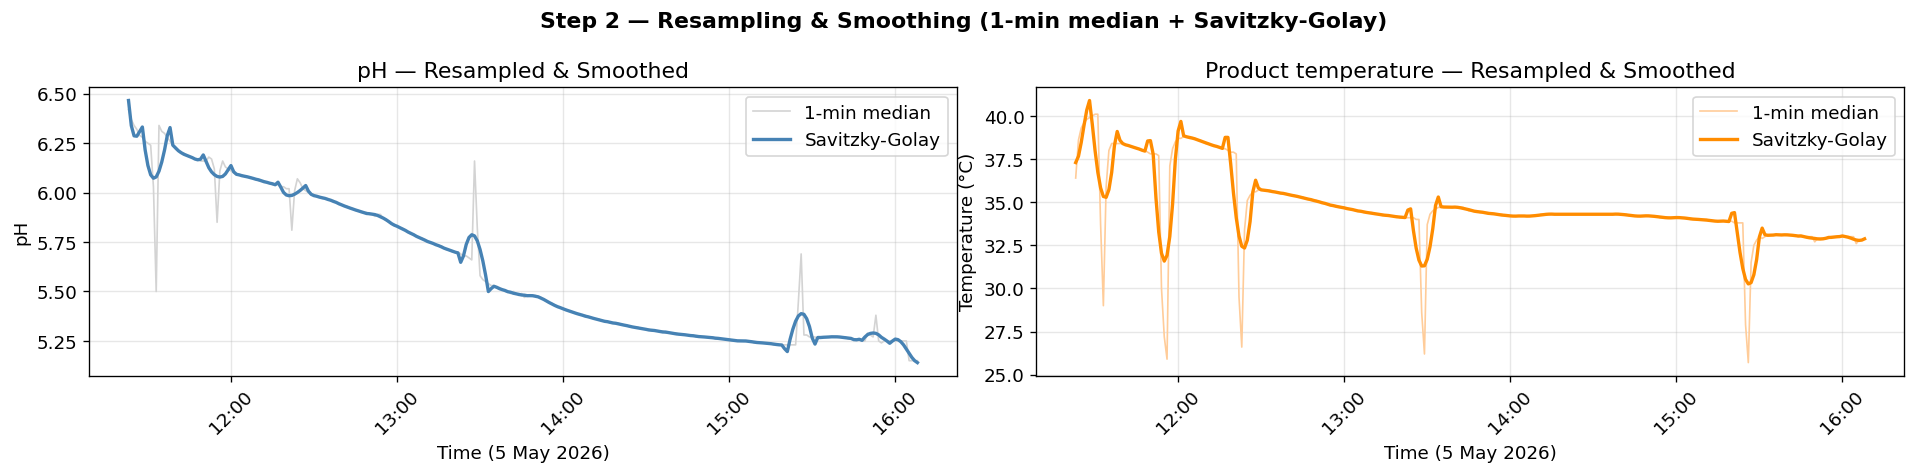

In [4]:
def resample_and_smooth(series, freq='1min', window=SG_WINDOW, poly=SG_POLY):
    resampled = series.resample(freq).median().dropna()
    if len(resampled) < window:
        return resampled, resampled.copy()
    smoothed = savgol_filter(resampled.values, window_length=window, polyorder=poly)
    return resampled, pd.Series(smoothed, index=resampled.index, name=series.name)

ph_res,   ph_smooth   = resample_and_smooth(df_ph['pH'])
temp_res, temp_smooth = resample_and_smooth(df_ph['temp_C'])
mV_res,   _           = resample_and_smooth(df_ph['mV'])

print(f'After resampling: {len(ph_res)} points')

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].plot(ph_res.index,   ph_res.values,   color='lightgrey', linewidth=1.0, label='1-min median')
axes[0].plot(ph_smooth.index, ph_smooth.values, color='steelblue', linewidth=2.0, label='Savitzky-Golay')
axes[0].set_title('pH — Resampled & Smoothed')
axes[0].set_ylabel('pH')
axes[0].legend()

axes[1].plot(temp_res.index,   temp_res.values,   color='#ffcc99', linewidth=1.0, label='1-min median')
axes[1].plot(temp_smooth.index, temp_smooth.values, color='darkorange', linewidth=2.0, label='Savitzky-Golay')
axes[1].set_title('Product temperature — Resampled & Smoothed')
axes[1].set_ylabel('Temperature (°C)')
axes[1].legend()

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.set_xlabel('Time (5 May 2026)')

plt.suptitle('Step 2 — Resampling & Smoothing (1-min median + Savitzky-Golay)', fontweight='bold')
plt.tight_layout()
plt.savefig('may5_02_resampling.png', bbox_inches='tight')
plt.show()

---
## 3. Elpro Temperature Alignment

The Elpro logs at **16 s** (ambient air temperature). Resample to 1-min to align with the pH grid.  
Values above 50 °C were already removed as artefacts (probe removal spikes).

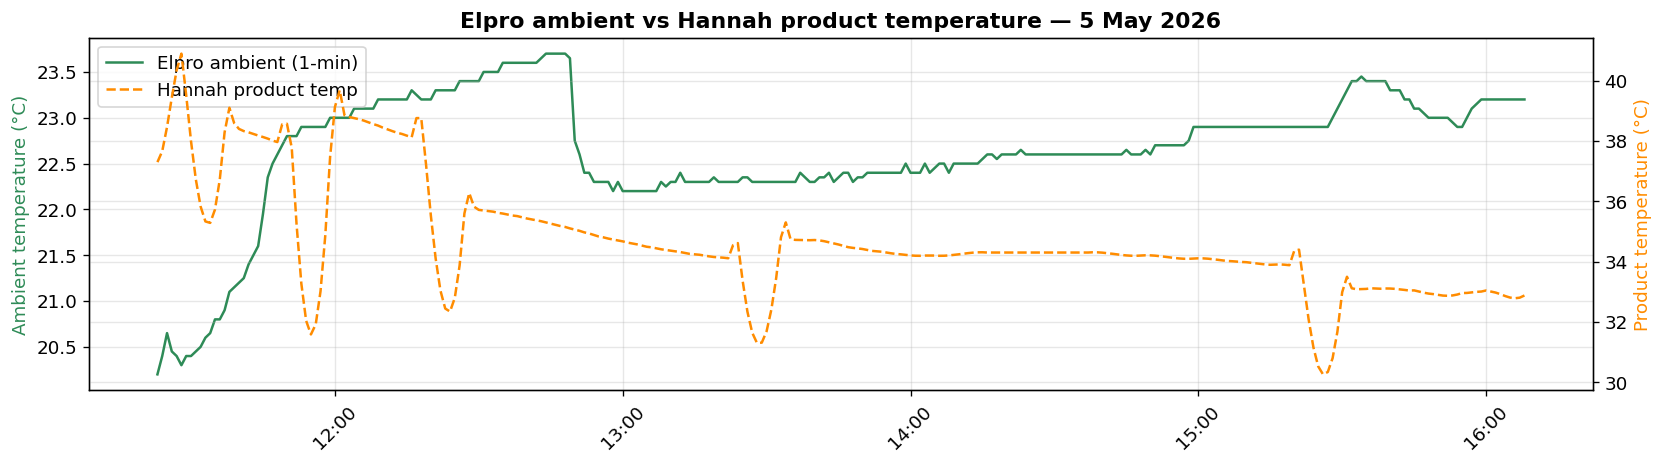

Mean ΔT product − ambient : 12.1 °C


In [5]:
# Resample Elpro 16s → 1min
elpro_1min = df_elpro['temp_C'].resample('1min').median().dropna()

# Restrict to pH measurement window
elpro_window = elpro_1min[
    (elpro_1min.index >= ph_res.index[0]) &
    (elpro_1min.index <= ph_res.index[-1])
]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(elpro_window.index, elpro_window.values, color='seagreen', linewidth=1.5, label='Elpro ambient (1-min)')
ax2 = ax.twinx()
ax2.plot(temp_smooth.index, temp_smooth.values, color='darkorange', linewidth=1.5, linestyle='--', label='Hannah product temp')
ax2.set_ylabel('Product temperature (°C)', color='darkorange')
ax.set_ylabel('Ambient temperature (°C)', color='seagreen')
ax.set_title('Elpro ambient vs Hannah product temperature — 5 May 2026', fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2)
plt.tight_layout()
plt.savefig('may5_03_temperature.png', bbox_inches='tight')
plt.show()

delta_T = temp_smooth.mean() - elpro_window.reindex(temp_smooth.index, method='nearest').mean()
print(f'Mean ΔT product − ambient : {delta_T:.1f} °C')

---
## 4. Nernst Correction

PHLOT002 measures product temperature directly → correction uses **measured T°**, not an assumption.  
This is more accurate than Session 1 (USB/Server used assumed 35 °C).

$$\mathrm{pH}_{\mathrm{corr}} = \mathrm{pH}_{\mathrm{iso}} + (\mathrm{pH}_{\mathrm{meas}} - \mathrm{pH}_{\mathrm{iso}}) \cdot \frac{T_{\mathrm{meas}}}{T_{\mathrm{cal}}}$$

Δ pH (corrected − measured):
count    286.0000
mean      -0.0434
std        0.0082
min       -0.0568
25%       -0.0508
50%       -0.0461
75%       -0.0373
max       -0.0203
dtype: float64


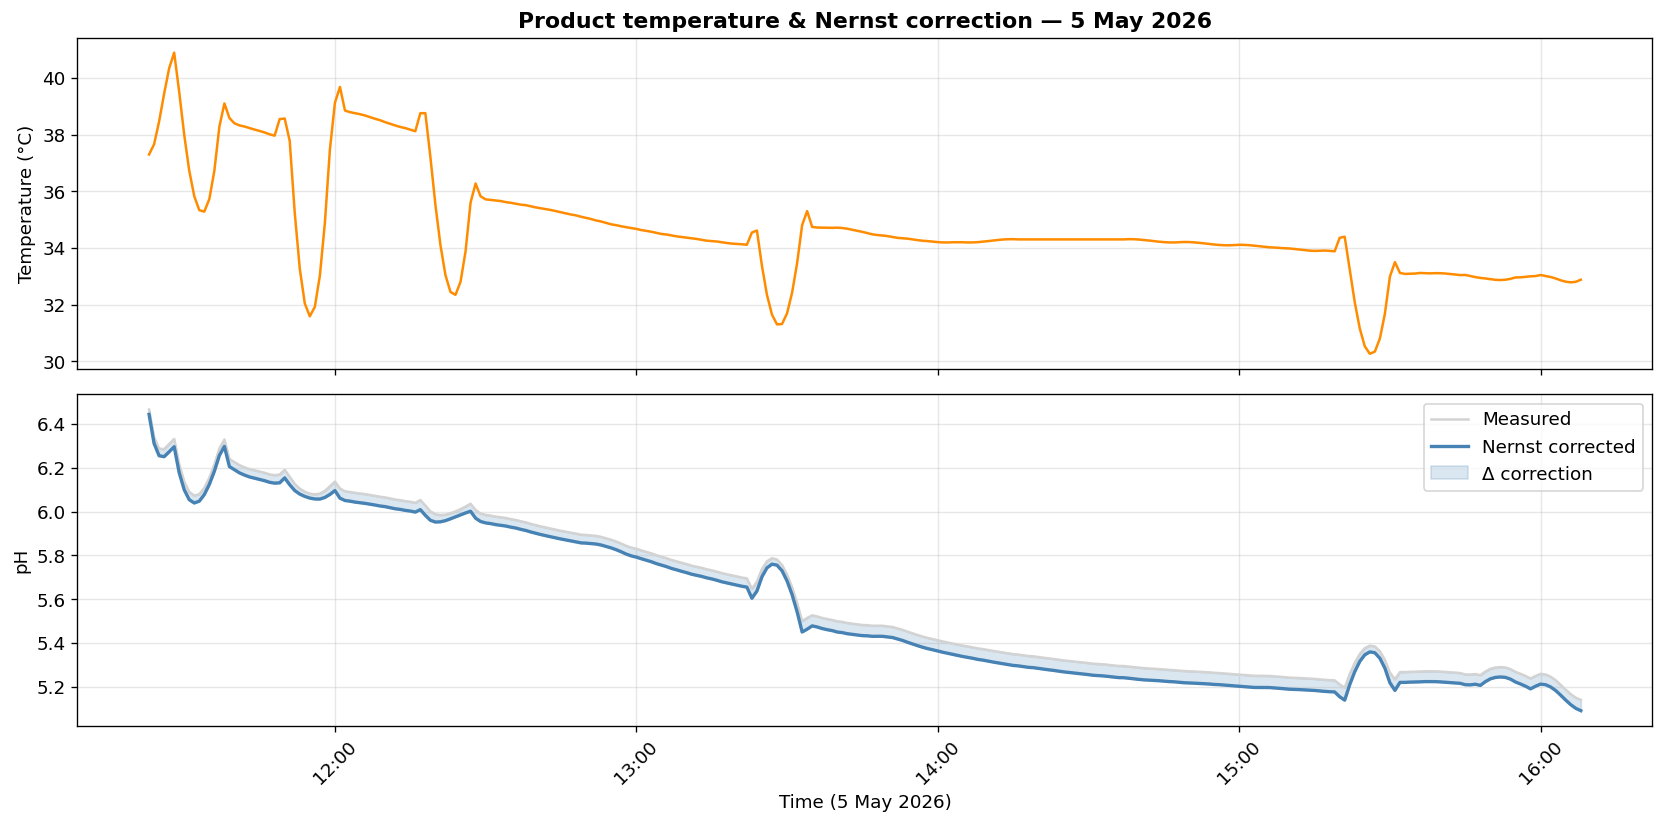

In [6]:
idx = ph_smooth.index.intersection(temp_smooth.index)
ph_corr = pd.Series(
    nernst_correct(ph_smooth.loc[idx].values, temp_smooth.loc[idx].values),
    index=idx, name='pH_corr'
)

delta = ph_corr - ph_smooth.loc[idx]
print('Δ pH (corrected − measured):')
print(delta.describe().round(4))

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(temp_smooth.index, temp_smooth.values, color='darkorange', linewidth=1.5)
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title('Product temperature & Nernst correction — 5 May 2026', fontweight='bold')

axes[1].plot(ph_smooth.loc[idx].index, ph_smooth.loc[idx].values,
             color='lightgrey', linewidth=1.5, label='Measured')
axes[1].plot(ph_corr.index, ph_corr.values,
             color='steelblue', linewidth=2.0, label='Nernst corrected')
axes[1].fill_between(ph_smooth.loc[idx].index,
                     ph_smooth.loc[idx].values, ph_corr.values,
                     alpha=0.2, color='steelblue', label='Δ correction')
axes[1].set_ylabel('pH')
axes[1].set_xlabel('Time (5 May 2026)')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axes[1].xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('may5_04_nernst.png', bbox_inches='tight')
plt.show()

---
## 5. Cross-Session Comparison — Session 1 (Hannah PHLOT001) vs Session 2 (PHLOT002)

Both sessions used the **same instrument model** (Hanna edge) and **same probe model** (FC2020).  
Profiles are aligned to **t = 0** (moment of first measurement) for shape comparison.

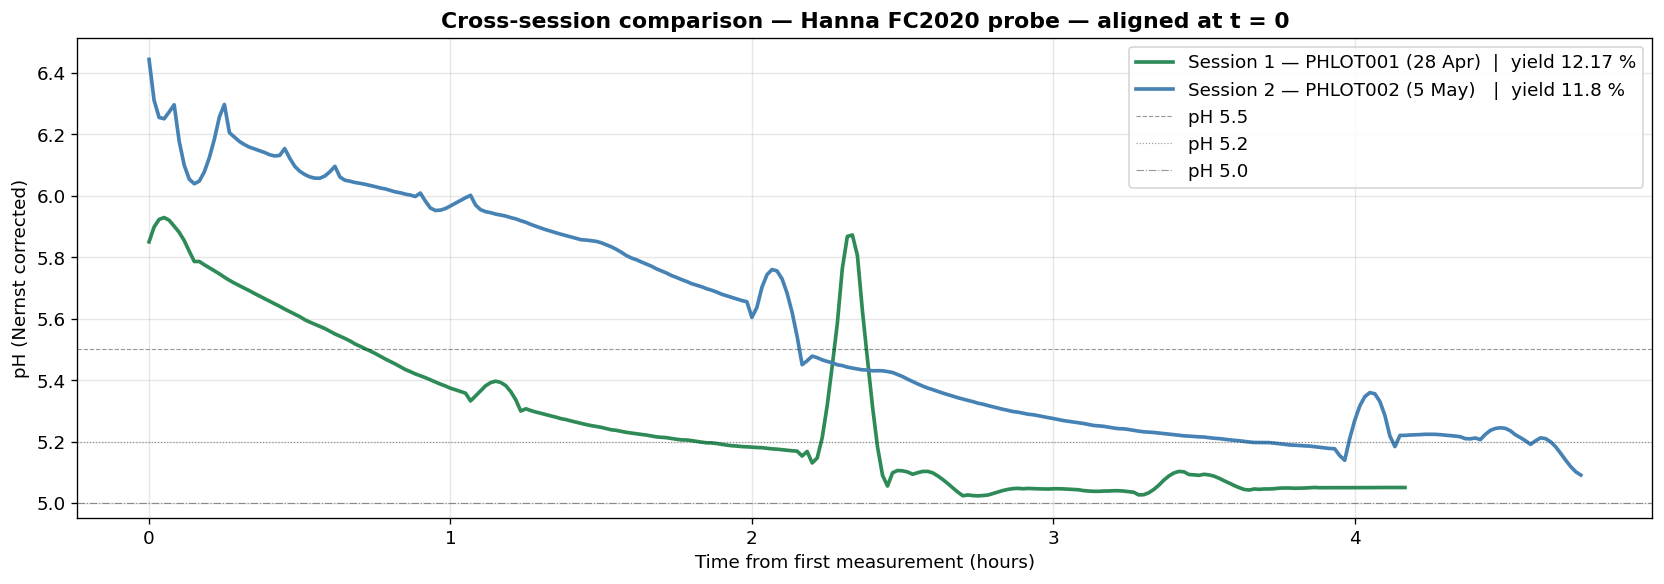

In [7]:
# ── Reload Session 1 Hannah (same pipeline as acidification_analysis.ipynb) ───
df3_raw = pd.read_csv(
    'data/trace pH fromage 3_28042026_hannah.csv',
    skiprows=20, header=None,
    names=['_', 'rec', 'date', 'time', 'pH', 'u1', 'mV', 'u2', 'temp_C', 'u3', '_2'],
    usecols=['date', 'time', 'pH', 'mV', 'temp_C'],
    encoding='latin-1',
)
df3_raw['datetime'] = pd.to_datetime(
    df3_raw['date'].str.strip() + ' ' + df3_raw['time'].str.strip(),
    format='%Y-%m-%d %H:%M:%S'
)
for col in ['pH', 'mV', 'temp_C']:
    df3_raw[col] = pd.to_numeric(df3_raw[col], errors='coerce')
df3 = df3_raw[['datetime','pH','mV','temp_C']].dropna().set_index('datetime').sort_index()
df3 = df3[(df3['pH'] >= 3.5) & (df3['pH'] <= 7.0)].copy()

# Apply same resampling + Nernst to Session 1
ph3_res, ph3_smooth   = resample_and_smooth(df3['pH'])
t3_res,  t3_smooth    = resample_and_smooth(df3['temp_C'])
idx3 = ph3_smooth.index.intersection(t3_smooth.index)
ph3_corr = pd.Series(
    nernst_correct(ph3_smooth.loc[idx3].values, t3_smooth.loc[idx3].values),
    index=idx3
)

# Align to t=0 (hours)
h1 = (ph3_corr.index  - ph3_corr.index[0]).total_seconds()  / 3600
h2 = (ph_corr.index   - ph_corr.index[0]).total_seconds()   / 3600

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(h1, ph3_corr.values, color='seagreen',  linewidth=2.2,
        label=f'Session 1 — PHLOT001 (28 Apr)  |  yield 12.17 %')
ax.plot(h2, ph_corr.values,  color='steelblue', linewidth=2.2,
        label=f'Session 2 — PHLOT002 (5 May)   |  yield 11.8 %')

for thr, ls in [(5.5, '--'), (5.2, ':'), (5.0, '-.')]:
    ax.axhline(thr, color='black', linewidth=0.7, linestyle=ls, alpha=0.4, label=f'pH {thr}')

ax.set_xlabel('Time from first measurement (hours)')
ax.set_ylabel('pH (Nernst corrected)')
ax.set_title('Cross-session comparison — Hanna FC2020 probe — aligned at t = 0', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('may5_05_comparison.png', bbox_inches='tight')
plt.show()

---
## 6. Feature Extraction

Quantify the **shape** of the acidification curve for each session.  
These features will serve as inputs to the quality model.

In [8]:
def extract_features(ph_series, temp_series, session_label):
    t = (ph_series.index - ph_series.index[0]).total_seconds() / 3600
    ph = ph_series.values

    dpdt = np.gradient(ph, t)
    max_rate_idx = np.argmin(dpdt)

    # Area under curve (trapezoidal) — higher = slower acidification
    auc = np.trapezoid(ph, t)

    return {
        'Session':             session_label,
        'pH_initial':          round(ph[0], 3),
        'pH_final':            round(ph[-1], 3),
        'delta_pH':            round(ph[-1] - ph[0], 3),
        'duration_h':          round(t[-1], 2),
        'max_rate_pH_per_h':   round(dpdt[max_rate_idx], 4),
        't_max_rate_h':        round(t[max_rate_idx], 2),
        'mean_temp_C':         round(temp_series.mean(), 1),
        'AUC_pH_h':            round(auc, 2),
    }

feat1 = extract_features(ph3_corr, t3_smooth.loc[idx3], 'Session 1 — 28 Apr')
feat2 = extract_features(ph_corr,  temp_smooth.loc[idx], 'Session 2 — 5 May')

df_feat = pd.DataFrame([feat1, feat2]).set_index('Session')
print('Acidification curve features:')
df_feat

Acidification curve features:


,pH_initial,pH_final,delta_pH,duration_h,max_rate_pH_per_h,t_max_rate_h,mean_temp_C,AUC_pH_h
Session,,,,,,,,
Session 1 — 28 Apr,5.850,5.050,-0.800,4.17,-10.1203,2.37,31.2,21.96
Session 2 — 5 May,6.444,5.091,-1.353,4.75,-7.9688,0.00,34.7,26.48


---
## 7. Quality Table

Combine extracted features with the **fresh yield** quality indicator.  

> ⚠️ With only 2 data points, no statistical model can be validated yet.  
> This table establishes the structure for future sessions.

In [9]:
yields = {'Session 1 — 28 Apr': 12.17, 'Session 2 — 5 May': 11.80}
milk_kg = {'Session 1 — 28 Apr': 282, 'Session 2 — 5 May': None}  # milk for S2 not recorded

df_quality = df_feat.copy()
df_quality['fresh_yield_%'] = pd.Series(yields)
df_quality['milk_kg']       = pd.Series(milk_kg)

print('Quality table (features + yield):')
df_quality[['pH_initial','pH_final','delta_pH','duration_h',
            'max_rate_pH_per_h','mean_temp_C','AUC_pH_h','fresh_yield_%']]

Quality table (features + yield):


,pH_initial,pH_final,delta_pH,duration_h,max_rate_pH_per_h,mean_temp_C,AUC_pH_h,fresh_yield_%
Session,,,,,,,,
Session 1 — 28 Apr,5.850,5.050,-0.800,4.17,-10.1203,31.2,21.96,12.17
Session 2 — 5 May,6.444,5.091,-1.353,4.75,-7.9688,34.7,26.48,11.80


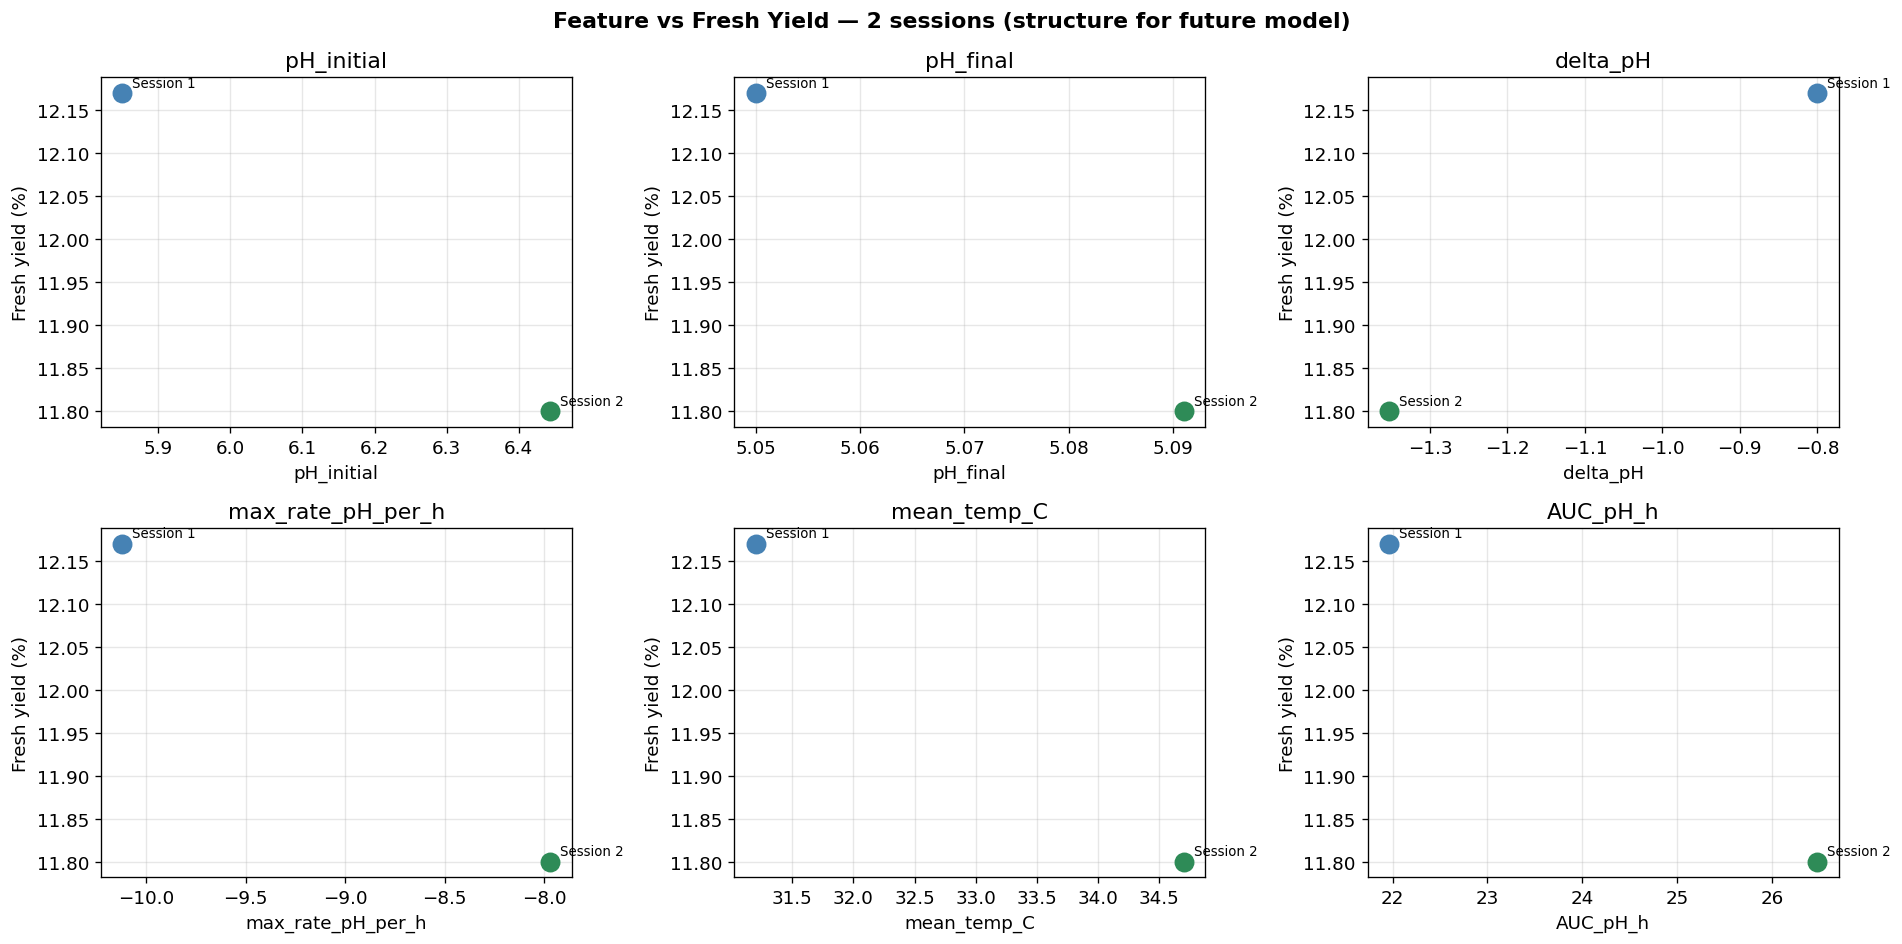


Note: 2 data points → visual structure only. Statistical model requires ≥ 10 sessions.


In [10]:
# Visual overview of features vs yield
features_to_plot = ['pH_initial', 'pH_final', 'delta_pH', 'max_rate_pH_per_h', 'mean_temp_C', 'AUC_pH_h']
colors = ['steelblue', 'seagreen']
sessions = df_quality.index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(features_to_plot):
    ax = axes[i]
    yields_vals = df_quality['fresh_yield_%'].values
    feat_vals   = df_quality[feat].values
    for j, (x, y, s, c) in enumerate(zip(feat_vals, yields_vals, sessions, colors)):
        ax.scatter(x, y, color=c, s=120, zorder=5)
        ax.annotate(s.split('—')[0].strip(), (x, y),
                    textcoords='offset points', xytext=(6, 4), fontsize=8)
    ax.set_xlabel(feat)
    ax.set_ylabel('Fresh yield (%)')
    ax.set_title(feat)

plt.suptitle('Feature vs Fresh Yield — 2 sessions (structure for future model)', fontweight='bold')
plt.tight_layout()
plt.savefig('may5_06_quality_scatter.png', bbox_inches='tight')
plt.show()

print('\nNote: 2 data points → visual structure only. Statistical model requires ≥ 10 sessions.')

---
## 8. Notes & Next Steps

### What this notebook demonstrates
- The 4-step pipeline (resample → smooth → Nernst → compare) works cleanly on Session 2 data
- PHLOT002 requires **no interpolation** — a cleaner dataset than Session 1
- The Nernst correction is **more accurate** in Session 2 (measured T° vs assumed 35 °C in S1)
- Feature extraction provides a reproducible, quantitative description of each acidification curve

### Limitations at this stage
- [ ] **2 sessions only** — no statistical model can be built or validated yet
- [ ] Session 2 pH measurement stopped at 5.15 — **fermentation not complete** at recording end
- [ ] Fresh yield is the **only quality metric** — texture, moisture, sensory scores needed
- [ ] Milk quantity for Session 2 not recorded (yield % not verifiable)
- [ ] True t=0 of fermentation (starter addition) unknown — alignment is to probe insertion, not process start

### To collect in future sessions
- [ ] Time of starter addition (true fermentation t=0)
- [ ] Milk mass and composition (fat %, protein %)
- [ ] Titratable acidity (°Dornic) at key time points
- [ ] Moisture / dry matter content of final cheese
- [ ] Rennet dose and curd-cut timing
- [ ] Whey volume drained
- [ ] Continue pH recording until target pH is reached (≤ 5.0)